# Scenario

A worked example of the `quicksat` scenario: a 510 km sun-synchronous orbit at 13:30 LTAN, flown for three orbits with a repeating list of five activities.

**Run all the cells.** The notebook runs `data/scenario.yaml` and writes the viewer. The viewer is the page `output/scenario_viewer.html`, next to this notebook: double-click it to open it. Below it, the activity table, a Gantt chart and two ground track maps are the first check of the activities.

For how each part works, such as the triggers, the statuses and how the orbit is built, see `docs/scenario/scenario_ref.ipynb`.

In [1]:
# Change log. LAST_CHANGE and CHANGE_NOTE are typed in by hand. Update them whenever
# the inputs change, such as an activity added, a duration changed or a new TLE, so
# that the figures below can be read against what produced them. The run time is recorded
# automatically, and says how stale the outputs stored in this notebook are relative
# to that last change.
from datetime import datetime

LAST_CHANGE = "2026-10-09"
CHANGE_NOTE = (
    "Three orbits of a 510 km sun-synchronous orbit at 13:30 LTAN, five activities, "
    "two of them ended by latitude crossings, slews at 0.7 deg/s, and the "
    "spacecraft's 3D model, whose wings turn to the sun and park in imaging."
)

print(f"last change  {LAST_CHANGE}")
print(f"             {CHANGE_NOTE}")
print(f"last run     {datetime.now().astimezone():%Y-%m-%d %H:%M %Z}")

last change  2026-10-09
             Three orbits of a 510 km sun-synchronous orbit at 13:30 LTAN, five activities, two of them ended by latitude crossings, slews at 0.7 deg/s, and the spacecraft's 3D model, whose wings turn to the sun and park in imaging.
last run     2026-10-09 15:32 CEST


In [2]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
from astropy import units as u
from IPython.display import Markdown, display

# Make the in-development quicksat package importable without installing it: walk up
# from the current directory to the repo root (the folder that holds the quicksat
# package) and switch to it. Works whether the notebook runs from sample/, the repo
# root, or the docs build.
here = Path.cwd()
repo_root = next(
    (p for p in (here, *here.parents) if (p / "quicksat" / "__init__.py").exists()),
    None,
)
if repo_root is None:
    raise RuntimeError("could not locate the quicksat repo root")
os.chdir(repo_root)

from quicksat.scenario.config import Scenario
from quicksat.scenario.plots import gantt_chart, ground_track_map
from quicksat.scenario.run import run_scenario
from quicksat.scenario.viewer import write_scenario_viewer
from quicksat.utils.intervals import duration
from quicksat.utils.plot_helpers import STYLE

plt.style.use(STYLE)

## Running the Scenario

The scenario file defines the orbit, the period of the run, the two attitudes and the activities. The activities after the eclipse end at crossings of 45° latitude, so the imaging always falls at the same place in the orbit.

The body turns between the two attitudes in slews, at the rate and acceleration of the file's `slew` block. Each slew takes the end of the activity before it, so each activity starts in its own attitude.

In [3]:
DATA = Path("sample") / "scenario" / "data"
scenario = Scenario.from_yaml_file(DATA / "scenario.yaml")

run = run_scenario(scenario)

eclipse_fraction = (duration(run.eclipses) / duration(run.interval)).to_value(u.one)

print(f"TLE epoch   {run.orbit.epoch.utc.isot} UTC")
print(f"run start   {run.times[0].utc.isot} UTC")
print(f"run end     {run.times[-1].utc.isot} UTC")
print(f"time step   {scenario.step:.0f}")
print(f"beta        {run.beta.min():.2f} to {run.beta.max():.2f}")
print(f"eclipses    {len(run.eclipses)}, {eclipse_fraction:.1%} of the run")

TLE epoch   2026-10-01T09:00:00.000 UTC
run start   2026-10-01T09:00:00.000 UTC
run end     2026-10-01T13:44:33.164 UTC
time step   10 s
beta        25.27 deg to 25.30 deg
eclipses    3, 36.2% of the run


## Visualising the results in the Viewer

The cell below writes the viewer into `sample/scenario/output/`:

- `scenario_viewer.html`, the page;
- `scenario.js`, the data of this run.

The page shows the run in 3D, with the ground track, the timeline and the activity table. During a slew, it names the attitude the body turns into, such as `nadir (slewing)`. The spacecraft is the 3D model `data/spacecraft.glb`, which `3d_model` names in the scenario file. Without it, the page draws a 1 m cube. The model's two wings turn about y to face the sun, and park at 0° in imaging, as the file's `articulations` set. The current data shows each wing's angle. The page needs no Python, no server and no network. Keep the two files together, because the page reads `scenario.js` from its own folder. To share the run, send the whole folder.

In [4]:
OUTPUT = Path("sample") / "scenario" / "output"
page = write_scenario_viewer(run, OUTPUT)

# The path is relative to the repository, so the stored output shows no local folders
display(
    Markdown(
        f"**The viewer is written:** `{page}`\n\n"
        "Double-click it in your file manager to open it."
    )
)

**The viewer is written:** `sample/scenario/output/scenario_viewer.html`

Double-click it in your file manager to open it.

## The activity table

One row for every occurrence of an activity, over the whole run. This is the first check of the activities: a status other than `ok` needs a look. The `slew [s]` column gives the time of the slew into each activity, settling included.

In [5]:
print(run.activity_summary)
run.activity_table.style.hide(axis="index").format(
    {"duration [min]": "{:.2f}", "outside [s]": "{:.1f}"}, na_rep=""
)

Occurrences: 13 in 3 repeats. Negative duration: 0. Outside constraint: 0. Event never came: 0. Cut at end: 1. Slew starts early: 0.


repeat,activity,start [UTC],end [UTC],duration [min],trigger,attitude,slew [s],mode,constraint,outside [s],status
1,1,2026-10-01T09:00:00.000,2026-10-01T09:30:10.628,30.18,eclipse entry,sun pointing,,idle,sunlit,0.0,ok
1,2,2026-10-01T09:30:10.628,2026-10-01T10:04:29.976,34.32,eclipse exit,nadir,193.364000,idle,eclipse,0.0,ok
1,3,2026-10-01T10:04:29.976,2026-10-01T10:44:48.589,40.31,latitude 45 deg -2 min,sun pointing,214.313000,idle,sunlit,0.0,ok
1,4,2026-10-01T10:44:48.589,2026-10-01T10:50:48.589,6.00,latitude 45 deg +4 min,nadir,91.900000,imaging,sunlit,0.0,ok
1,5,2026-10-01T10:50:48.589,2026-10-01T11:00:48.589,10.00,10 min,nadir,,downlink,,,ok
2,1,2026-10-01T11:00:48.589,2026-10-01T11:05:01.279,4.21,eclipse entry,sun pointing,159.302000,idle,sunlit,0.0,ok
2,2,2026-10-01T11:05:01.279,2026-10-01T11:39:20.569,34.32,eclipse exit,nadir,193.368000,idle,eclipse,0.0,ok
2,3,2026-10-01T11:39:20.569,2026-10-01T12:19:39.644,40.32,latitude 45 deg -2 min,sun pointing,214.317000,idle,sunlit,0.0,ok
2,4,2026-10-01T12:19:39.644,2026-10-01T12:25:39.644,6.00,latitude 45 deg +4 min,nadir,91.938000,imaging,sunlit,0.0,ok
2,5,2026-10-01T12:25:39.644,2026-10-01T12:35:39.644,10.00,10 min,nadir,,downlink,,,ok


## The Gantt chart

The illumination, the attitude and the mode against time. A grey bar in the attitude row is a slew. A problem would show in red.

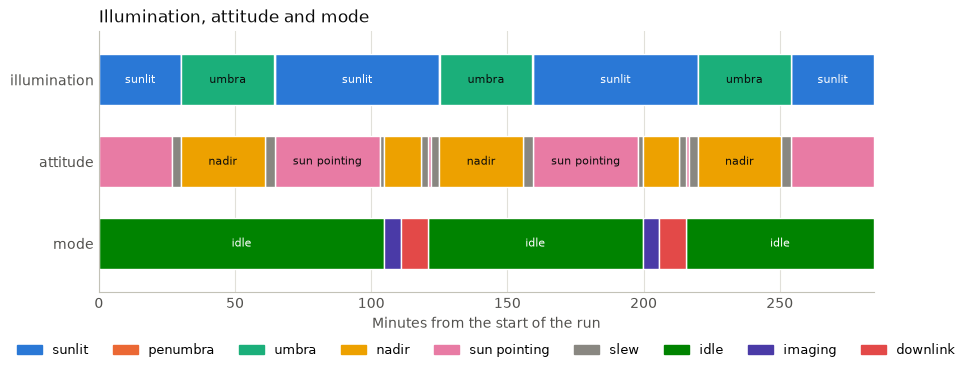

In [6]:
gantt_chart(run)
plt.show()

## The ground tracks

One map coloured by mode, and one by attitude. The circle marks the start of the run, and the square its end.

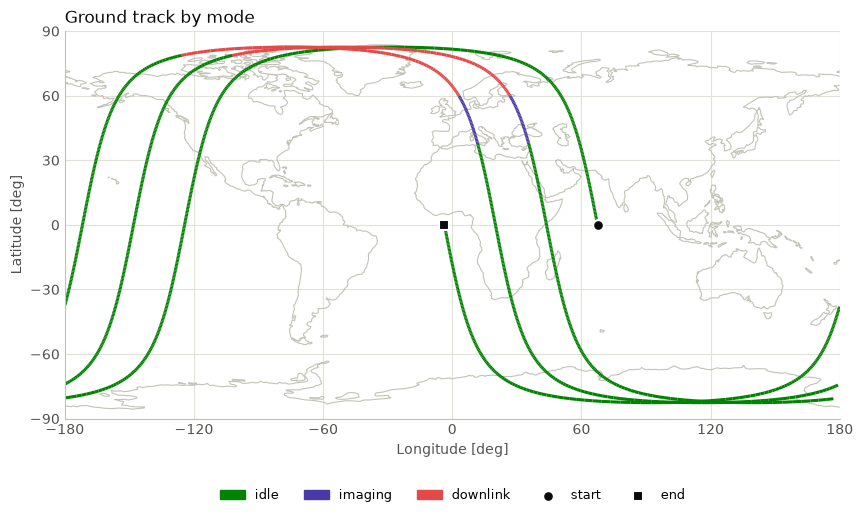

In [7]:
ground_track_map(run, run.mode, "Ground track by mode")
plt.show()

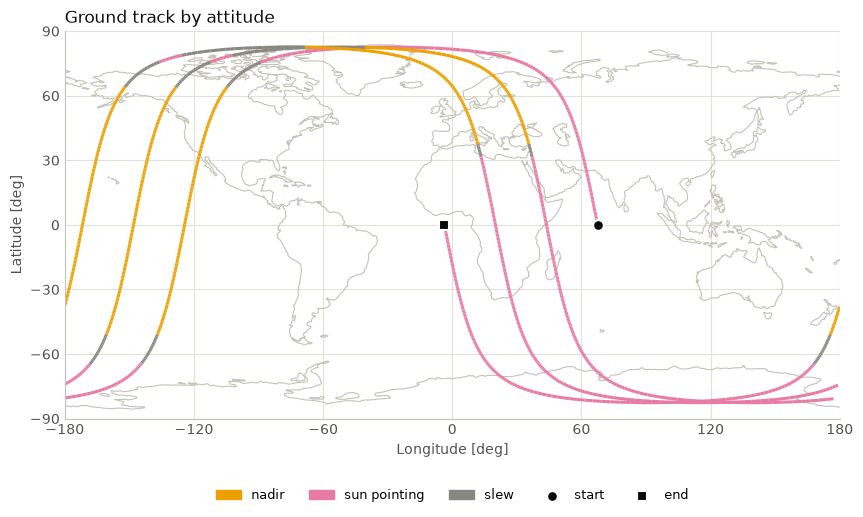

In [8]:
ground_track_map(run, run.attitude, "Ground track by attitude")
plt.show()

## Changing the scenario

Edit `sample/scenario/data/scenario.yaml` and run the notebook again from the top. The notebook never writes that file.

For example, end the first activity a minute early, with `eclipse entry - 1 min`. The nadir activity after it then starts a minute before the eclipse, in sunlight. Its `eclipse` constraint fails by 60 s in each repeat, and the Gantt chart marks it with a red box.

To turn to nadir a minute before the eclipse, give that minute an activity of its own, `[eclipse entry, nadir, idle, sunlit]`, before the eclipse activity. It ends at the eclipse entry, and every constraint holds again.

Or change the slews. A higher `max_rate` shortens them. Without the `slew` block, every attitude change is instant.

Or change the wings. Without `park`, they track the sun in imaging too. A `range`, such as `[-90 deg, 90 deg]`, stops them at its ends.